# 02b · Personalization, second attempt

Phase 2 found that personal features from a person's first 1–3 nights didn't improve staging.
Phase 2b tests three more designs. Each was fixed in `docs/decisions.md` (35–38) and committed
before any run. All use the same folds, seeds and evaluation nights (night 4 onward of the 43
subjects with at least 4 nights) as Phase 2.

| Method | Uses labels of the person's nights? | Model | Control |
|---|---|---|---|
| **A** `expanding_norm`: baseline from *all* earlier nights | no | trees and GRU | population model (same training nights) |
| **B** `context`: learned summary of the earlier nights | no | GRU | `context_shuffled`: same model, another person's nights |
| **C** `finetune`: fine-tune the population GRU on earlier nights | yes (upper bound) | GRU | `finetune_other`: fine-tune on another person's nights |

`all` means "every night before the one being staged"; 1–3 means "the first N nights".
Primary result: pooled 5-class kappa difference against the control, paired subject
bootstrap. Nothing here is fitted or tuned; the notebook only reads saved runs.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sleepwatch.config import get_settings
from sleepwatch.models.metrics import per_group_scores

RESULTS = get_settings().results_dir
index = pd.read_csv(RESULTS / "index.csv")
latest = index[~index["partial"]].groupby("name").tail(1).set_index("name")


def load(name):
    run_dir = RESULTS / name / latest.loc[name, "run"]
    return {
        "metrics": json.loads((run_dir / "metrics.json").read_text()),
        "pred": pd.read_parquet(run_dir / "predictions.parquet"),
        "run": json.loads((run_dir / "run.json").read_text()),
    }


names = ["gru_personal", "hgb_expanding", "gru_main", "hgb_main"]
runs = {name: load(name) for name in names}
display(latest.loc[names, ["run", "model", "commit", "dirty", "kappa_5", "macro_f1_5"]])
assert not latest.loc[names, "dirty"].any(), "a run was made from uncommitted code"
assert latest.loc[names, "commit"].nunique() == 1, "runs come from different commits"

COLORS = {
    "population": "#a9a8a3",
    "expanding_norm": "#2a78d6",
    "context": "#2a78d6",
    "context_shuffled": "#a9a8a3",
    "finetune": "#eb6834",
    "finetune_other": "#a9a8a3",
    "prior_stage": "#7e57c2",
}
plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#a9a8a3",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "lines.linewidth": 1.5,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "font.size": 9,
        "legend.frameon": False,
    }
)


def ci(d):
    return f"{d['diff']:+.3f} [{d['ci95'][0]:+.3f}, {d['ci95'][1]:+.3f}]"

,run,model,commit,dirty,kappa_5,macro_f1_5
name,,,,,,
gru_personal,20261001T231831Z,gru,69468d94,False,0.5100,0.5665
hgb_expanding,20261002T084238Z,hgb,69468d94,False,0.3815,0.5039
gru_main,20261002T083326Z,gru,69468d94,False,0.5100,0.5665
hgb_main,20261002T090148Z,hgb,69468d94,False,0.3815,0.5039


## 1 · Primary results

One row per personalized variant. *vs control* is the method's own control (for A, the
population model). A difference whose CI excludes 0 is marked; with about 12 comparisons, a
single such result is weak evidence on its own.

In [2]:
CONTROL = {
    "expanding_norm": "population",
    "context": "context_shuffled",
    "finetune": "finetune_other",
}
rows = []
for name, methods in [
    ("hgb_expanding", ["expanding_norm"]),
    ("gru_personal", ["expanding_norm", "context", "finetune"]),
]:
    curve_all = runs[name]["metrics"]["n_curve"]
    for method in methods:
        curve = curve_all[method]
        for key in [k for k in curve if k != "0"]:
            entry = curve[key]
            ref = CONTROL[method]
            versus = entry["vs_population"] if ref == "population" else entry[f"vs_{ref}"]
            low, high = versus["5"]["kappa"]["ci95"]
            rows.append(
                {
                    "model": name.split("_")[0],
                    "method": method,
                    "nights": key,
                    "kappa": round(entry["5"]["pooled"]["kappa"], 3),
                    "vs control (kappa)": ci(versus["5"]["kappa"]),
                    "vs population (kappa)": ci(entry["vs_population"]["5"]["kappa"]),
                    "vs control (macro-F1)": ci(versus["5"]["macro_f1"]),
                    "vs control (4-class kappa)": ci(versus["4"]["kappa"]),
                    "CI excludes 0": "yes" if low > 0 or high < 0 else "",
                    "_diff": versus["5"]["kappa"]["diff"],
                    "_low": low,
                    "_high": high,
                }
            )
primary = pd.DataFrame(rows)
display(primary.drop(columns=["_diff", "_low", "_high"]))
for method in ["context_shuffled", "finetune_other"]:
    curve = runs["gru_personal"]["metrics"]["n_curve"][method]
    print(
        f"{method} (control) vs population, kappa: "
        + "; ".join(
            f"{k}: {ci(v['vs_population']['5']['kappa'])}" for k, v in curve.items() if k != "0"
        )
    )

,model,method,nights,kappa,vs control (kappa),vs population (kappa),vs control (macro-F1),vs control (4-class kappa),CI excludes 0
0,hgb,expanding_norm,all,0.386,"-0.004 [-0.011, +0.004]","-0.004 [-0.011, +0.004]","-0.003 [-0.010, +0.003]","-0.003 [-0.013, +0.007]",
1,gru,expanding_norm,all,0.522,"-0.007 [-0.019, +0.005]","-0.007 [-0.019, +0.005]","-0.006 [-0.016, +0.004]","-0.004 [-0.018, +0.009]",
2,gru,context,all,0.521,"-0.006 [-0.025, +0.018]","-0.008 [-0.022, +0.005]","-0.005 [-0.021, +0.015]","-0.002 [-0.026, +0.027]",
3,gru,finetune,all,0.543,"+0.034 [+0.015, +0.055]","+0.014 [-0.002, +0.029]","+0.025 [+0.011, +0.041]","+0.041 [+0.018, +0.067]",yes
4,gru,finetune,1,0.533,"+0.022 [+0.009, +0.035]","+0.004 [-0.008, +0.016]","+0.015 [+0.003, +0.029]","+0.024 [+0.007, +0.039]",yes
5,gru,finetune,2,0.539,"+0.033 [+0.015, +0.055]","+0.010 [-0.004, +0.022]","+0.028 [+0.011, +0.048]","+0.039 [+0.016, +0.065]",yes
6,gru,finetune,3,0.538,"+0.035 [+0.015, +0.061]","+0.009 [-0.006, +0.024]","+0.027 [+0.010, +0.047]","+0.040 [+0.015, +0.071]",yes


context_shuffled (control) vs population, kappa: all: -0.002 [-0.027, +0.017]
finetune_other (control) vs population, kappa: all: -0.020 [-0.039, -0.004]; 1: -0.018 [-0.032, -0.006]; 2: -0.023 [-0.044, -0.007]; 3: -0.026 [-0.048, -0.008]


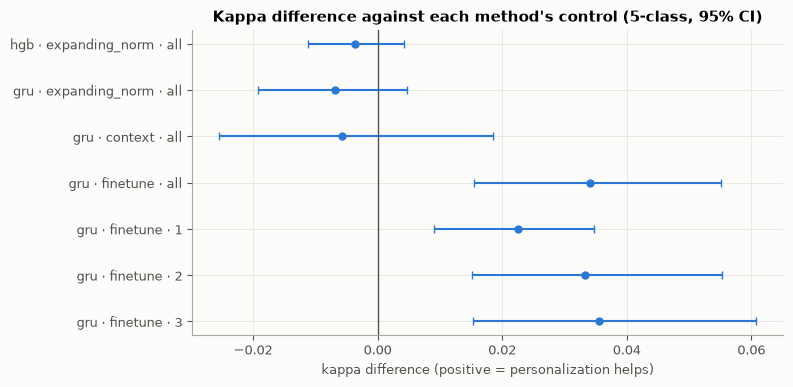

In [3]:
fig, ax = plt.subplots(figsize=(8, 0.42 * len(primary) + 1))
labels = [f"{r.model} · {r.method} · {r.nights}" for r in primary.itertuples()]
y = np.arange(len(primary))[::-1]
ax.errorbar(
    primary["_diff"],
    y,
    xerr=[primary["_diff"] - primary["_low"], primary["_high"] - primary["_diff"]],
    fmt="o",
    color="#2a78d6",
    ecolor="#2a78d6",
    capsize=3,
    ms=5,
)
ax.axvline(0, color="#52514e", lw=1)
ax.set_yticks(y, labels)
ax.set(
    title="Kappa difference against each method's control (5-class, 95% CI)",
    xlabel="kappa difference (positive = personalization helps)",
)
plt.tight_layout()
plt.show()

## 2 · Fine-tuning by number of nights

Fine-tuning on the person's own nights vs on another person's nights of the same count, next
to the population GRU and Phase 2's label-using upper bound (`prior_stage`, from `gru_main`).
All points are scored on the same evaluation nights.

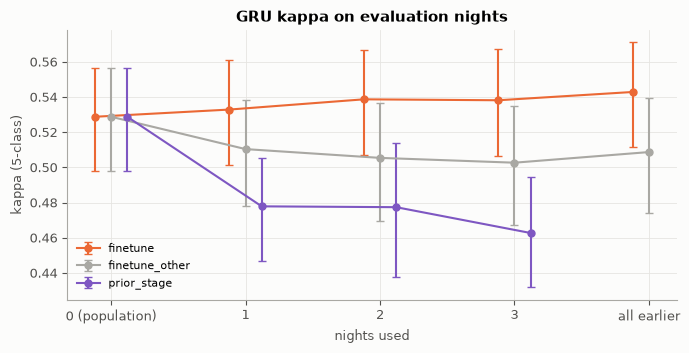

Validation kappa of each fine-tuning setting per fold (chosen = column maximum):


fold,0,1,2,3,4
setting,,,,,
"lr 0.0001, 20 ep, all",0.473,0.541,0.582,0.563,0.600
"lr 0.0001, 20 ep, output",0.457,0.534,0.570,0.567,0.595
"lr 0.0001, 5 ep, all",0.459,0.535,0.579,0.568,0.598
"lr 0.0001, 5 ep, output",0.455,0.533,0.569,0.568,0.593
"lr 0.001, 20 ep, all",0.432,0.531,0.570,0.536,0.553
"lr 0.001, 20 ep, output",0.482,0.534,0.556,0.554,0.596
"lr 0.001, 5 ep, all",0.464,0.544,0.573,0.539,0.586
"lr 0.001, 5 ep, output",0.460,0.536,0.571,0.565,0.596


chosen: {0: {'lr': 0.001, 'epochs': 20, 'layers': 'output'}, 1: {'lr': 0.001, 'epochs': 5, 'layers': 'all'}, 2: {'lr': 0.0001, 'epochs': 20, 'layers': 'all'}, 3: {'lr': 0.0001, 'epochs': 5, 'layers': 'output'}, 4: {'lr': 0.0001, 'epochs': 20, 'layers': 'all'}}


In [4]:
fig, ax = plt.subplots(figsize=(7, 3.6))
positions = {"0": 0, "1": 1, "2": 2, "3": 3, "all": 4}
sources = [
    ("finetune", runs["gru_personal"], -0.12),
    ("finetune_other", runs["gru_personal"], 0.0),
    ("prior_stage", runs["gru_main"], 0.12),
]
for method, run, offset in sources:
    curve = run["metrics"]["n_curve"][method]
    keys = [k for k in positions if k in curve]
    k = np.array([curve[key]["5"]["pooled"]["kappa"] for key in keys])
    bounds = np.array([curve[key]["5"]["ci95"]["kappa"] for key in keys])
    ax.errorbar(
        np.array([positions[key] for key in keys]) + offset,
        k,
        yerr=[k - bounds[:, 0], bounds[:, 1] - k],
        color=COLORS[method],
        marker="o",
        ms=5,
        capsize=3,
        label=method,
    )
ax.set_xticks(list(positions.values()), ["0 (population)", "1", "2", "3", "all earlier"])
ax.set(title="GRU kappa on evaluation nights", xlabel="nights used", ylabel="kappa (5-class)")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

grid = []
for entry in runs["gru_personal"]["run"]["folds"]:
    for g in entry["finetune"]["validation_kappa"]:
        grid.append(
            {
                "fold": entry["fold"],
                "setting": f"lr {g['lr']:g}, {g['epochs']} ep, {g['layers']}",
                "validation kappa": g["kappa"],
            }
        )
grid = pd.DataFrame(grid).pivot(index="setting", columns="fold", values="validation kappa")
print("Validation kappa of each fine-tuning setting per fold (chosen = column maximum):")
display(grid.round(3))
print(
    "chosen:", {e["fold"]: e["finetune"]["setting"] for e in runs["gru_personal"]["run"]["folds"]}
)

## 3 · Training of the learned summary (method B)

Validation macro-F1 (on held-out *training* subjects) at the best epoch, per fold. If the
summary carried useful person information, `context` should beat `context_shuffled` here too;
if it let the model memorize training subjects, training would stop early with a lower score.

In [5]:
hist = []
for entry in runs["gru_personal"]["run"]["folds"]:
    for variant in ["population_0", "expanding_norm_-1", "context_-1", "context_shuffled_-1"]:
        h = entry[variant]
        hist.append(
            {
                "fold": entry["fold"],
                "variant": variant.rsplit("_", 1)[0],
                "validation macro-F1": round(h["val_macro_f1"], 3),
                "best epoch": h["best_epoch"],
                "epochs run": h["epochs_run"],
            }
        )
hist = pd.DataFrame(hist)
display(hist.pivot(index="fold", columns="variant", values="validation macro-F1"))
display(hist.pivot(index="fold", columns="variant", values="best epoch"))

variant,context,context_shuffled,expanding_norm,population
fold,,,,
0,0.533,0.539,0.543,0.537
1,0.559,0.585,0.567,0.594
2,0.592,0.567,0.591,0.596
3,0.594,0.599,0.596,0.599
4,0.604,0.605,0.608,0.601


variant,context,context_shuffled,expanding_norm,population
fold,,,,
0,17,31,17,17
1,7,25,7,31
2,32,11,24,24
3,18,25,18,20
4,19,19,19,17


## 4 · Which stages change

F1 per stage on the evaluation nights (5-class), for the population GRU and each `all`-nights
variant. Fine-tuning on nights without N1 could push N1 down; this shows whether it did.

In [6]:
stage_rows = []
for method in [
    "population",
    "expanding_norm",
    "context",
    "context_shuffled",
    "finetune",
    "finetune_other",
]:
    curve = runs["gru_personal"]["metrics"]["n_curve"]
    entry = curve["expanding_norm"]["0"] if method == "population" else curve[method]["all"]
    pooled = entry["5"]["pooled"]
    stage_rows.append(
        {
            "variant": method,
            **{k[3:]: round(v, 3) for k, v in pooled.items() if k.startswith("f1_")},
            "ECE": round(pooled["ece"], 3),
        }
    )
display(pd.DataFrame(stage_rows))

,variant,Wake,N1,N2,N3,REM,ECE
0,population,0.691,0.159,0.672,0.696,0.684,0.024
1,expanding_norm,0.691,0.144,0.659,0.697,0.681,0.026
2,context,0.670,0.139,0.667,0.702,0.679,0.018
3,context_shuffled,0.685,0.148,0.670,0.698,0.681,0.043
4,finetune,0.701,0.153,0.684,0.715,0.692,0.022
5,finetune_other,0.656,0.154,0.661,0.674,0.674,0.038


## 5 · Spread across people

Pooled differences can hide a few people who gain a lot. Per-subject kappa difference
against the control on the evaluation nights (43 subjects), for the `all`-nights variants.
Descriptive only: with 2–6 evaluation nights per person, single-person differences are noisy.

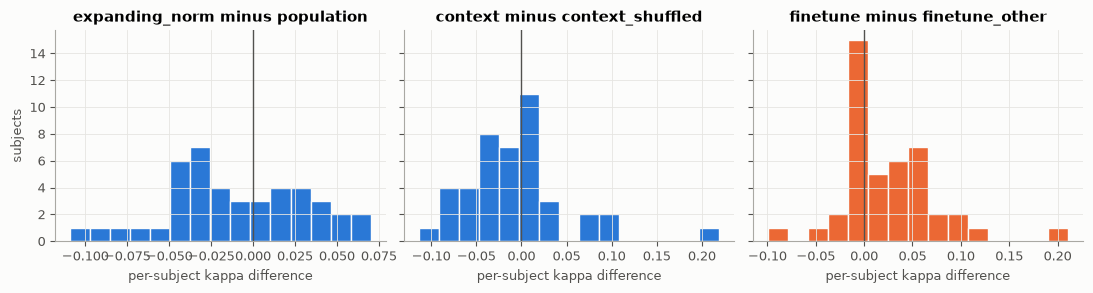

,method,subjects,median,better,worse,largest gain,largest loss
0,expanding_norm,43,-0.014,18,25,0.070,-0.109
1,context,43,-0.008,18,25,0.219,-0.113
2,finetune,43,0.012,30,13,0.211,-0.100


In [7]:
pred = runs["gru_personal"]["pred"]


def per_subject(method, n):
    rows = pred[(pred["method"] == method) & (pred["n_prior"] == n)]
    if method == "population":
        rows = pred[(pred["method"] == "population") & pred["eval_night"]]
    return per_group_scores(rows, ["subject"])["kappa"]


fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
summary = []
for ax, (method, ref) in zip(
    axes,
    [
        ("expanding_norm", "population"),
        ("context", "context_shuffled"),
        ("finetune", "finetune_other"),
    ],
    strict=True,
):
    diff = per_subject(method, -1) - per_subject(ref, -1 if ref != "population" else 0)
    ax.hist(diff, bins=15, color=COLORS[method], edgecolor="#fcfcfb")
    ax.axvline(0, color="#52514e", lw=1)
    ax.set(title=f"{method} minus {ref}", xlabel="per-subject kappa difference")
    summary.append(
        {
            "method": method,
            "subjects": len(diff),
            "median": round(diff.median(), 3),
            "better": int((diff > 0).sum()),
            "worse": int((diff < 0).sum()),
            "largest gain": round(diff.max(), 3),
            "largest loss": round(diff.min(), 3),
        }
    )
axes[0].set_ylabel("subjects")
plt.tight_layout()
plt.show()
display(pd.DataFrame(summary))

## 6 · Consistency with Phase 2

The population models here are retrained from the same code, folds and seeds as Phase 2, so
their predictions must match `gru_main` and `hgb_main` exactly.

In [8]:
for new, old in [("gru_personal", "gru_main"), ("hgb_expanding", "hgb_main")]:
    a = runs[new]["pred"].query("method == 'population'").reset_index(drop=True)
    b = runs[old]["pred"].query("method == 'population'").reset_index(drop=True)
    pd.testing.assert_frame_equal(a, b)
    print(f"{new} population == {old} population ({len(a)} epochs)")

gru_personal population == gru_main population (215914 epochs)
hgb_expanding population == hgb_main population (215914 epochs)


## 7 · Findings

**Neither label-free design helped.**
- **A, the baseline from all earlier nights:**
  - trees −0.004 [−0.011, +0.004];
  - GRU −0.007 [−0.019, +0.005] against the population model.
- **B, the learned summary:** −0.006 [−0.025, +0.018] against the same model given another
  person's nights, and −0.008 [−0.022, +0.005] against the population model.
  - The model given the person's own nights did no better than with someone else's, so the
    summary carried no usable information about the person.
  - Its validation scores and stopping epochs look like the population GRU's: no sign that it
    memorized training subjects, and no sign that it learned anything personal either.

**Fine-tuning on the person's labelled nights shows a person-specific signal, but little net
gain.**
- **Against fine-tuning on another person's nights:** +0.022 to +0.035 kappa. All four CIs
  exclude 0, and macro-F1 and 4-class kappa agree.
- **That control is not neutral:** fine-tuning on someone else's nights costs 0.018–0.026 kappa
  against the population model.
- **Against the population model itself:** the gain is only +0.004 to +0.014, and every CI
  includes 0. The best case is all earlier nights: +0.014 [−0.002, +0.029].
- **Per person** (all earlier nights): 30 of 43 do better than with another person's nights
  (median +0.012).
- **Stages and calibration:** Wake, N2, N3 and REM F1 rise by 0.01–0.02, N1 is unchanged, and
  calibration doesn't worsen (ECE 0.022 vs 0.024).
- **Fine-tuning vs features:** on the same evaluation nights, fine-tuning reaches kappa
  0.533–0.543. Phase 2's `prior_stage` uses the same labels as features and reaches 0.463–0.478.
  These two weren't compared formally (paired).
- **The chosen setting varied between folds:** validation kappas of the 8 settings were close,
  within about 0.05 in each fold, so the grid choice is noisy.

**What this means.** Phase 2 and 2b together tested five ways to use a person's earlier nights
without labels: `prior_norm` and this phase's expanding baseline, each with trees and the GRU,
plus the learned summary. None improved staging. The person-specific signal appears only when
EEG-scored labels of the person's own nights are available, and even then the gain over the
population model is small and not significant. Watch heart rate and movement under the existing
within-night normalization seem to leave little person-level information for these designs to
add. That reading is consistent with the results but untested.

**Caveats.** There are 7 primary comparisons with no multiplicity correction. The 4 that exclude 0
are all the same method and agree with each other. Each person has 2–6 evaluation nights, so
per-person differences are noisy. Everything above was fixed in `docs/decisions.md` 35–38 before
the runs.